Francisco Benita, 2026

In [1]:
## Replace the urls by the gpkg files provided in Zenodo

Jakarta_indicators = {
	"grid400m" : "https://www.dropbox.com/scl/fi/4vzwp6eo41z0prel0jft7/Jakarta_Urban_Indicators_400m.gpkg?rlkey=hnte8cv2jyzsg0fo0zx5pzc77&st=a0x74ovx&dl=1",
	"grid800m" : "https://www.dropbox.com/scl/fi/aa7wjacxw8ecls0qnq051/Jakarta_Urban_Indicators_800m.gpkg?rlkey=dejmhj6pxxn3xqkjnz5hk19ig&st=oe63wfu3&dl=1",
	"grid1200m" : "https://www.dropbox.com/scl/fi/v982qklq3s5k93na8fds7/Jakarta_Urban_Indicators_1200m.gpkg?rlkey=tycxn5o7vd1ilbtrq7mn3gzmv&st=jngubrnn&dl=1"
}

Manila_indicators = {
	"grid400m" : "https://www.dropbox.com/scl/fi/t16zhhjoqfr6foespb8n1/Manila_Urban_Indicators_400m.gpkg?rlkey=pz9c349cy55wgh2a6x1xzmk7p&st=jxr3s25b&dl=1",
	"grid800m" : "https://www.dropbox.com/scl/fi/prmitvnirikph0d6g4uzr/Manila_Urban_Indicators_800m.gpkg?rlkey=ghb1mz9rov95c7xy4vtglqvzq&st=vjefmvrt&dl=1",
	"grid1200m" : "https://www.dropbox.com/scl/fi/wrg38lvowvvzat0t38trv/Manila_Urban_Indicators_1200m.gpkg?rlkey=6ut8k6gdezrlpcrmn4hqi2cgw&st=mrqxm4g7&dl=1"
}

Manila_indicators = {
	"grid400m" : "https://www.dropbox.com/scl/fi/t16zhhjoqfr6foespb8n1/Manila_Urban_Indicators_400m.gpkg?rlkey=pz9c349cy55wgh2a6x1xzmk7p&st=jxr3s25b&dl=1",
	"grid800m" : "https://www.dropbox.com/scl/fi/prmitvnirikph0d6g4uzr/Manila_Urban_Indicators_800m.gpkg?rlkey=ghb1mz9rov95c7xy4vtglqvzq&st=vjefmvrt&dl=1",
	"grid1200m" : "https://www.dropbox.com/scl/fi/wrg38lvowvvzat0t38trv/Manila_Urban_Indicators_1200m.gpkg?rlkey=6ut8k6gdezrlpcrmn4hqi2cgw&st=mrqxm4g7&dl=1"
}

HMC_indicators = {
	"grid400m" : "https://www.dropbox.com/scl/fi/u0zkbyy9s0jk6y7mpp6ax/HMC_Urban_Indicators_400m.gpkg?rlkey=piq3wgrdqwx1vuosf8mp0ncxz&st=eitws1vm&dl=1",
	"grid800m" : "https://www.dropbox.com/scl/fi/cc4pxkghe04cgfz2vfspa/HMC_Urban_Indicators_800m.gpkg?rlkey=ckmqyfmemkzz5iaeria4fu9kk&st=2oj35svi&dl=1",
	"grid1200m" : "https://www.dropbox.com/scl/fi/k7fqhlpp2nrsok5x5pd4o/HMC_Urban_Indicators_1200m.gpkg?rlkey=t5mmr1549p40etmierawi6h5z&st=f1ldmpxj&dl=1"
}

PP_indicators = {
	"grid400m" : "https://www.dropbox.com/scl/fi/her5ea8bqkhsqa026v9p6/PP_Urban_Indicators_400m.gpkg?rlkey=gsp9mq8eoc0bz6syf7vp8gxu4&st=s88j88iz&dl=1",
	"grid800m" : "https://www.dropbox.com/scl/fi/t941p0p971u5bibaziyeb/PP_Urban_Indicators_800m.gpkg?rlkey=xd1j7eflxyk04byfsv6a7xenw&st=9k8h0d7b&dl=1",
	"grid1200m" : "https://www.dropbox.com/scl/fi/g06cz61556sd9amy9m3ft/PP_Urban_Indicators_1200m.gpkg?rlkey=cdcqoyp6h0w4l8bcrm9k7yilr&st=n261xir2&dl=1"
}

In [2]:
!pip install matplotlib-scalebar

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/u0zkbyy9s0jk6y7mpp6ax/HMC_Urban_Indicators_400m.gpkg?rlkey=piq3wgrdqwx1vuosf8mp0ncxz&st=eitws1vm&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/cc4pxkghe04cgfz2vfspa/HMC_Urban_Indicators_800m.gpkg?rlkey=ckmqyfmemkzz5iaeria4fu9kk&st=2oj35svi&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/k7fqhlpp2nrsok5x5pd4o/HMC_Urban_Indicators_1200m.gpkg?rlkey=t5mmr1549p40etmierawi6h5z&st=f1ldmpxj&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/tmp/ipykernel_1671/2128725540.py:54: UserWarning: This figure includes Axes that are not compat

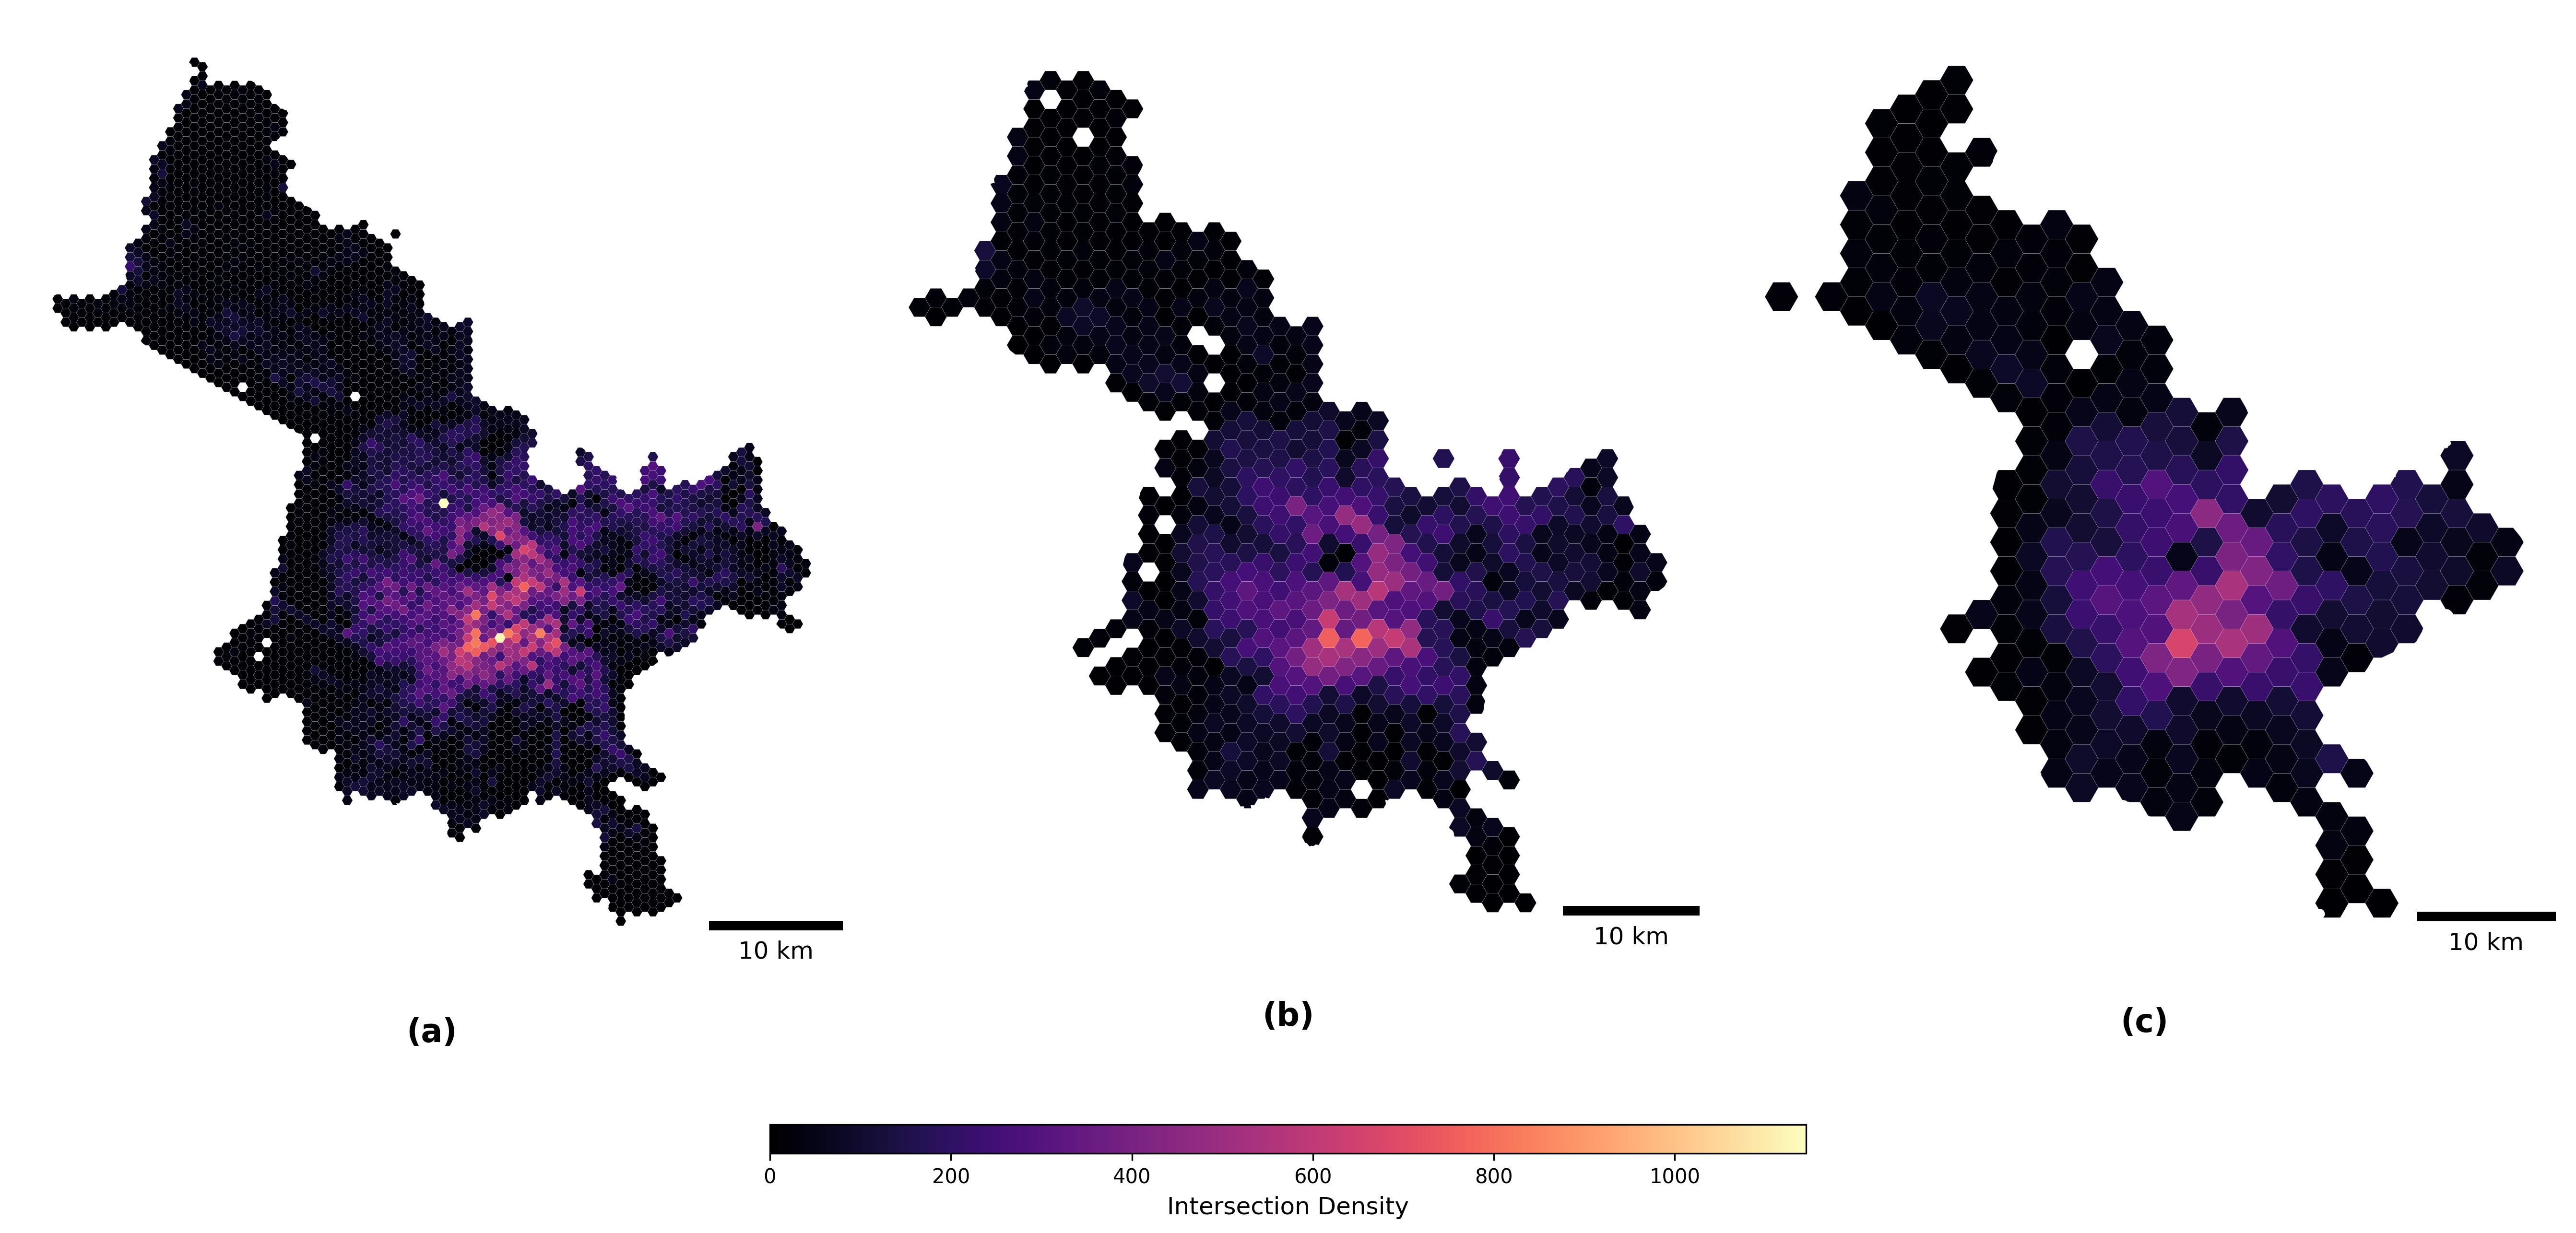

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
from matplotlib_scalebar.scalebar import ScaleBar

# 1. Load and project to a local UTM zone (UTM 48N for HMC) for accurate metric scaling
utm_crs = "EPSG:32648"
gdf_400 = gpd.read_file(HMC_indicators['grid400m']).to_crs(utm_crs)
gdf_800 = gpd.read_file(HMC_indicators['grid800m']).to_crs(utm_crs)
gdf_1200 = gpd.read_file(HMC_indicators['grid1200m']).to_crs(utm_crs)

# 2. Synchronize color scale
indicator = 'intersection_density'
all_values = pd.concat([gdf_400[indicator], gdf_800[indicator], gdf_1200[indicator]])
vmin, vmax = all_values.min(), all_values.max()

# 3. Setup the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 10), dpi=300)
cmap = 'magma'
gdfs = [gdf_400, gdf_800, gdf_1200]
titles = ["(a)", "(b)", "(c)"]

for ax, gdf, title in zip(axes, gdfs, titles):
    # Plot map
    gdf.plot(
        column=indicator,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor='white',
        linewidth=0.05
    )

    # Add Scale Bar (1 unit = 1 meter since we projected to UTM)
    scalebar = ScaleBar(1, units="m", location="lower right",
                        frameon=False, color="black",
                        font_properties={'size': 12})
    ax.add_artist(scalebar)

     # Place caption below each subplot
    ax.text(0.5, -0.05, title, transform=ax.transAxes,
            ha='center', va='top', fontsize=16, fontweight='bold')
    ax.axis('off')

# 4. Shared colorbar
cax = fig.add_axes([0.3, 0.1, 0.4, 0.02])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('Intersection Density', fontsize=12)

plt.tight_layout(rect=[0, 0.12, 1, 1])

# 5. Export the figure
plt.savefig('HMC_MAUP_Analysis.png', bbox_inches='tight', dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/4vzwp6eo41z0prel0jft7/Jakarta_Urban_Indicators_400m.gpkg?rlkey=hnte8cv2jyzsg0fo0zx5pzc77&st=a0x74ovx&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/aa7wjacxw8ecls0qnq051/Jakarta_Urban_Indicators_800m.gpkg?rlkey=dejmhj6pxxn3xqkjnz5hk19ig&st=oe63wfu3&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/v982qklq3s5k93na8fds7/Jakarta_Urban_Indicators_1200m.gpkg?rlkey=tycxn5o7vd1ilbtrq7mn3gzmv&st=jngubrnn&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vs

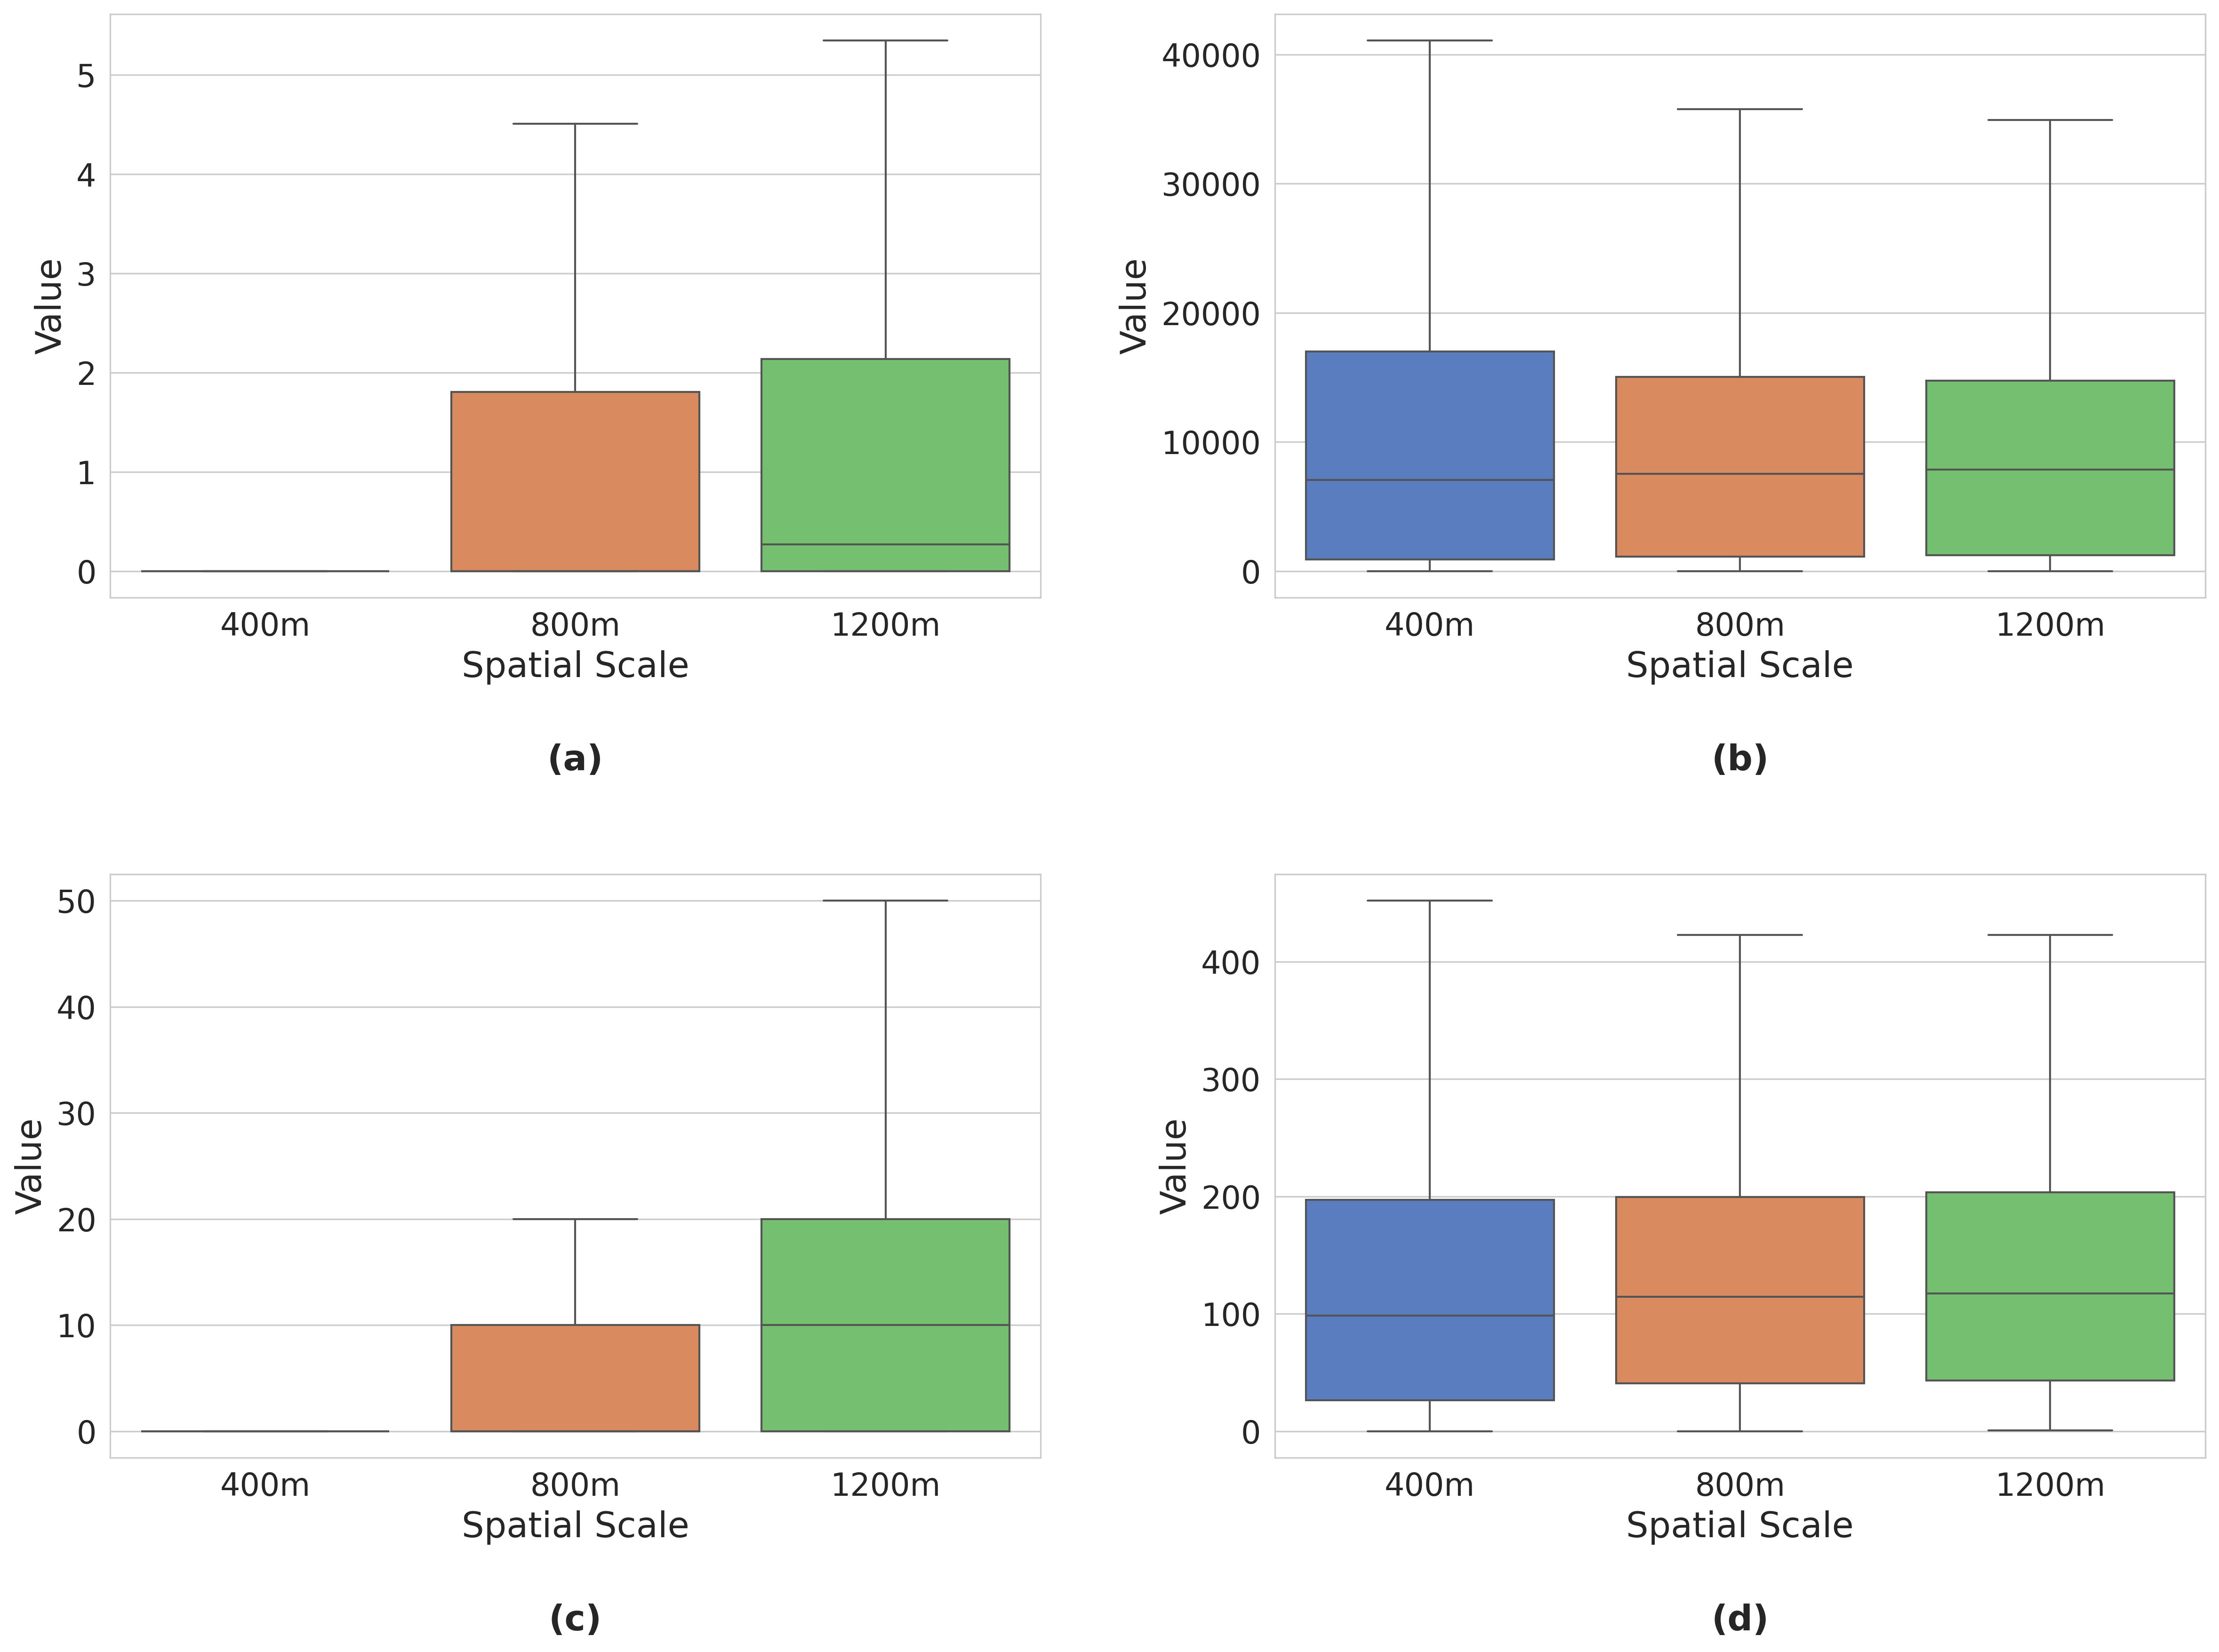

In [5]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the cities and scales to iterate through
city_data = {
    'Jakarta': Jakarta_indicators,
    'Manila': Manila_indicators,
    'HMC': HMC_indicators,
    'PP': PP_indicators
}
scales = ['grid400m', 'grid800m', 'grid1200m']
indicators = ['healthcare_density', 'population_density_km2', 'elevation_range', 'intersection_density']

all_dfs = []

# 1. Load and aggregate all 12 files
for city_name, scale_dict in city_data.items():
    for scale in scales:
        gdf = gpd.read_file(scale_dict[scale])
        gdf['City'] = city_name
        gdf['Scale'] = scale.replace('grid', '')
        cols_to_keep = indicators + ['City', 'Scale']
        all_dfs.append(gdf[cols_to_keep].copy())

# 2. Concatenate into a master DataFrame
master_df = pd.concat(all_dfs, ignore_index=True)

# 3. Setup plotting style
sns.set_style("whitegrid")
# Increase global font sizes
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16
})
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
axes = axes.flatten()

# 4. Generate boxplots for each indicator
labels = ['(a)', '(b)', '(c)', '(d)']   # <-- add this before the loop

for i, indicator in enumerate(indicators):
    sns.boxplot(
        data=master_df,
        x='Scale',
        y=indicator,
        hue='Scale',
        ax=axes[i],
        palette="muted",
        showfliers=False,
        legend=False,
        order=['400m', '800m', '1200m']
    )

    #axes[i].set_title(f'Distribution of {indicator.replace("_", " ").title()}', fontsize=20, fontweight='bold', pad=15)
    axes[i].set_title("")
    axes[i].set_xlabel('Spatial Scale', fontsize=18)
    axes[i].set_ylabel('Value', fontsize=18)
    # Larger tick labels
    axes[i].tick_params(axis='both', labelsize=16)
    # Panel labels BELOW each subplot
    #axes[i].text(0.5, -0.22, labels[i], transform=axes[i].transAxes, fontsize=18, fontweight='bold', va='top', ha='center')
    # Combined panel caption BELOW subplot
    caption = labels[i]
    axes[i].text(
      0.5, -0.25,
      caption,
      transform=axes[i].transAxes,
      fontsize=18,
      fontweight='bold',
      ha='center',
      va='top'
    )
plt.tight_layout(h_pad=3.0, w_pad=2.5)
plt.savefig('Regional_MAUP_Sensitivity_Boxplots.png', bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/4vzwp6eo41z0prel0jft7/Jakarta_Urban_Indicators_400m.gpkg?rlkey=hnte8cv2jyzsg0fo0zx5pzc77&st=a0x74ovx&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/aa7wjacxw8ecls0qnq051/Jakarta_Urban_Indicators_800m.gpkg?rlkey=dejmhj6pxxn3xqkjnz5hk19ig&st=oe63wfu3&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsicurl/https://www.dropbox.com/scl/fi/v982qklq3s5k93na8fds7/Jakarta_Urban_Indicators_1200m.gpkg?rlkey=tycxn5o7vd1ilbtrq7mn3gzmv&st=jngubrnn&dl=1 has GPKG application_id, but non conformant file extension
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: File /vs

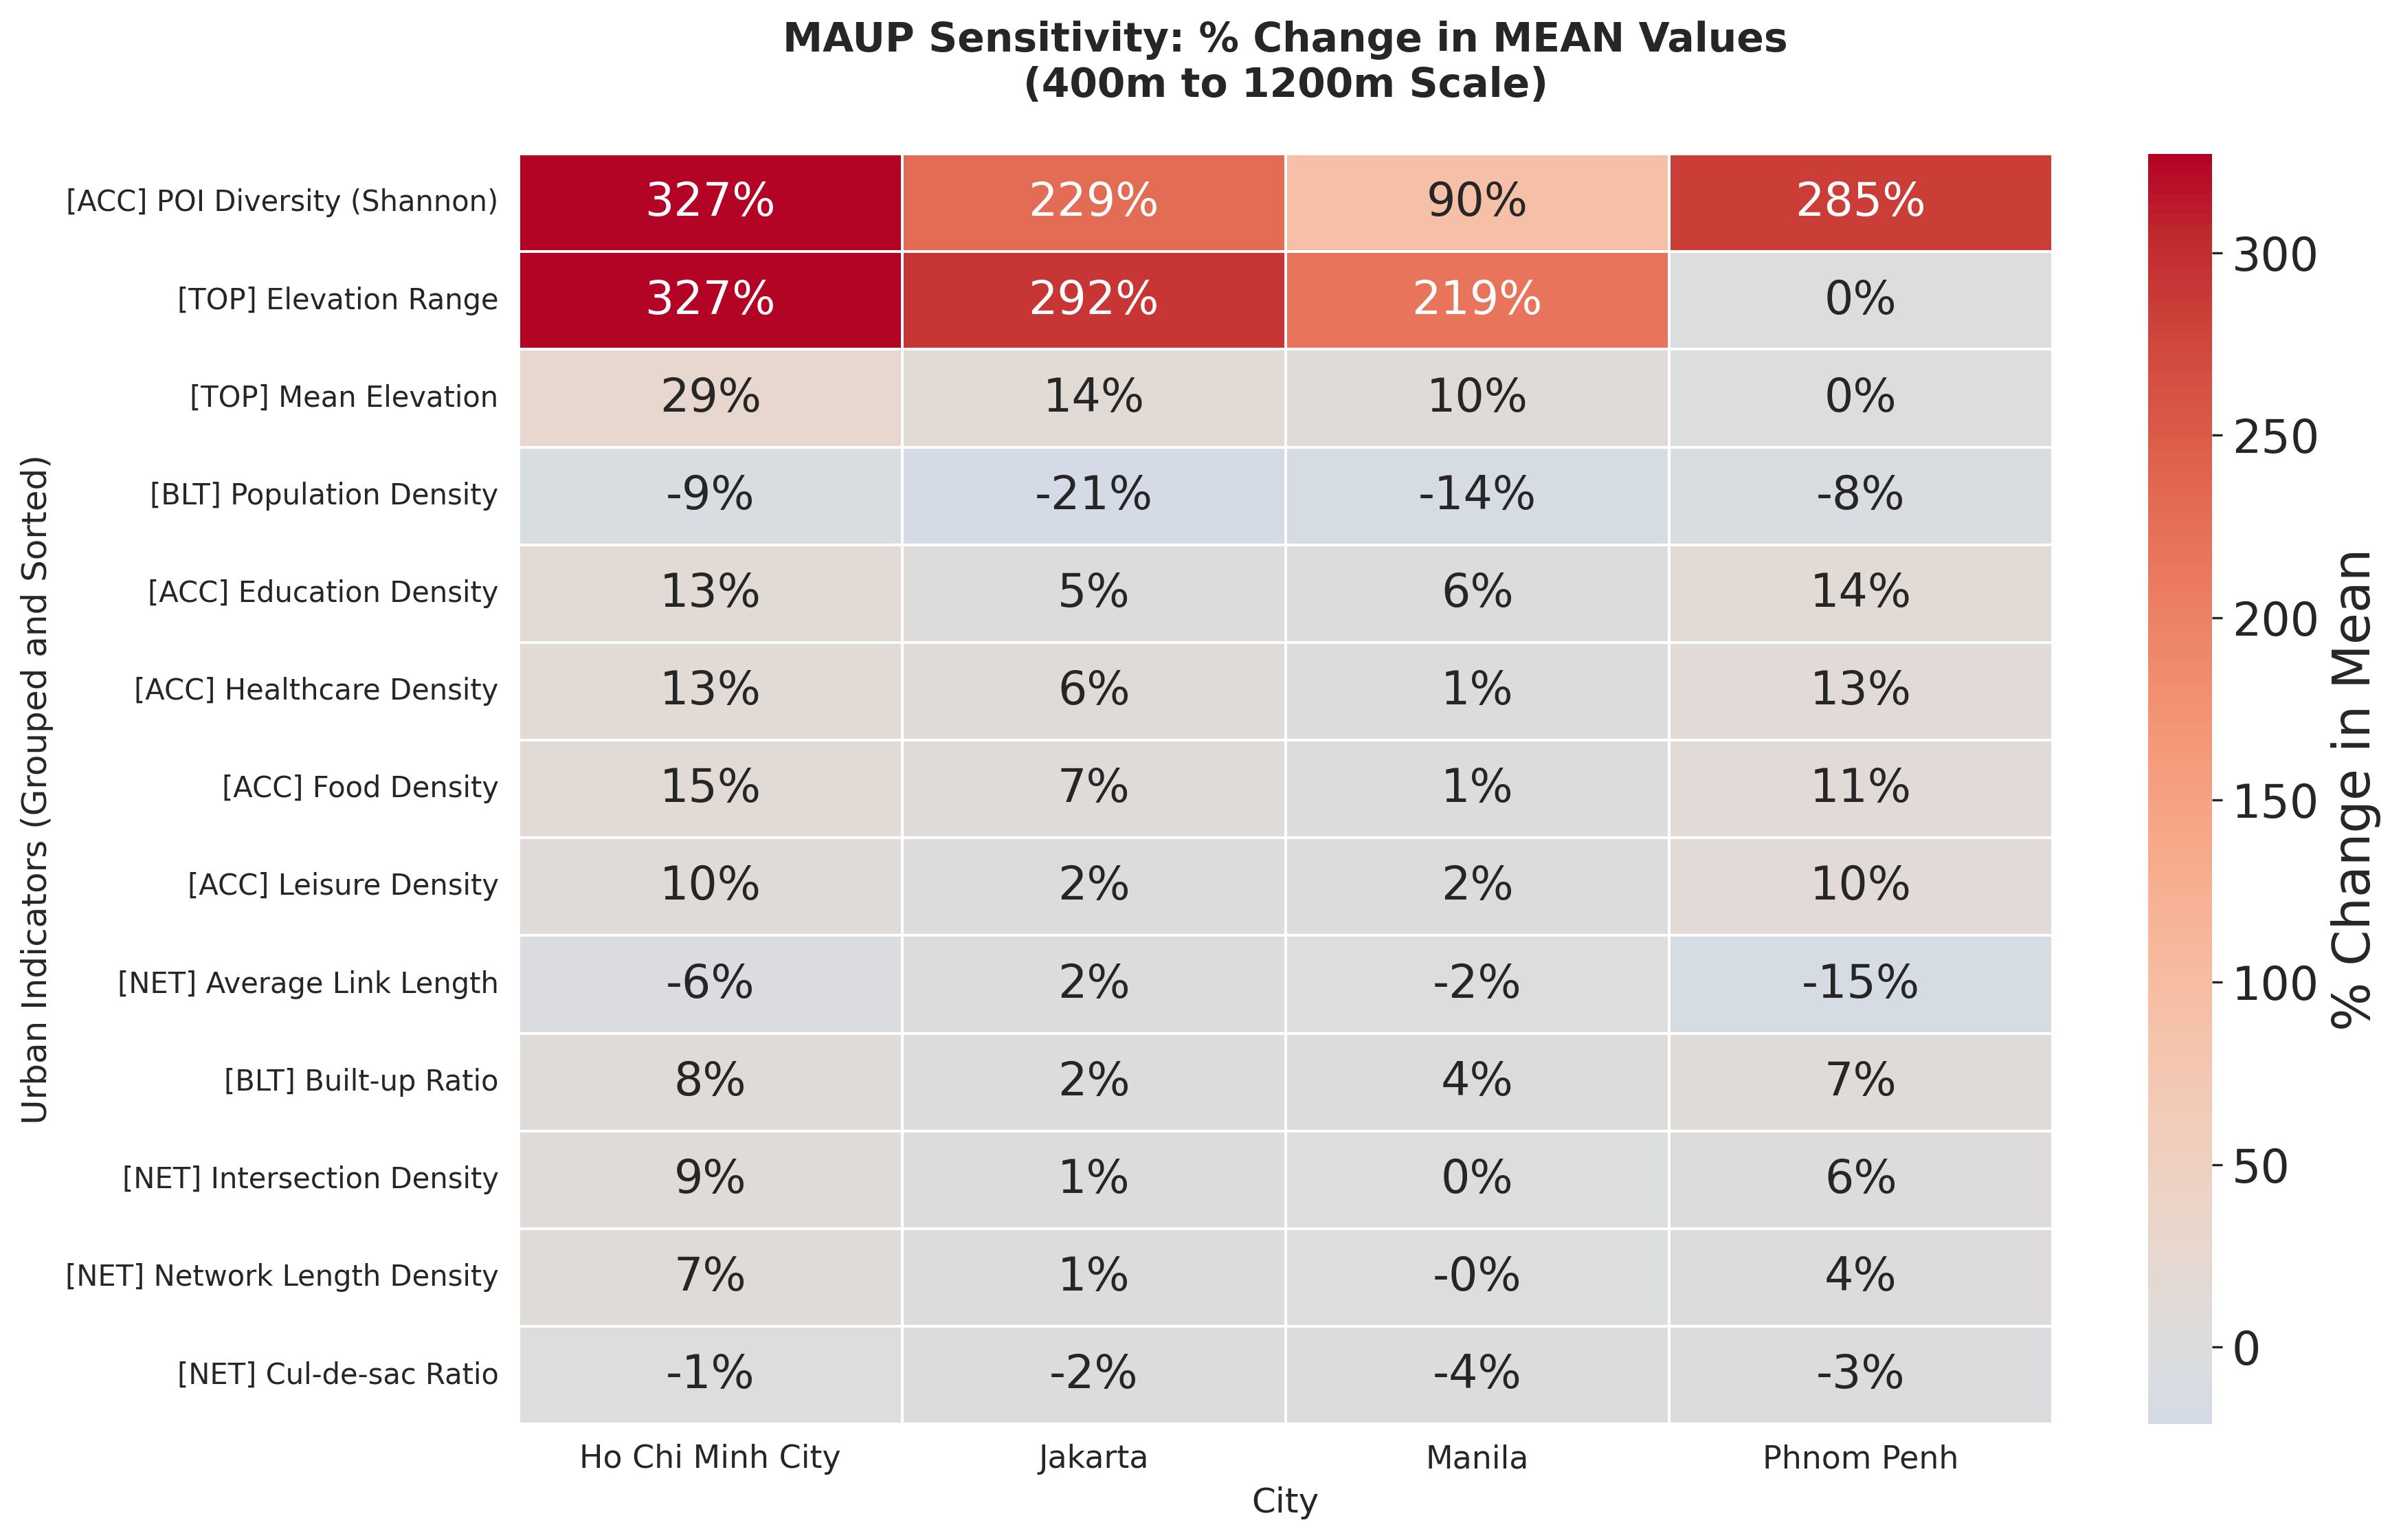

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

# 1. Define the 13 indicators
indicators = [
    'food_density', 'education_density', 'healthcare_density',
    'leisure_density', 'shannon_diversity', 'built_up_ratio',
    'population_density_km2', 'mean_elevation', 'elevation_range',
    'network_length_density', 'intersection_density',
    'cul_de_sac_ratio', 'avg_link_length'
]

# Re-extract/Load full master dataframe with all indicators
all_dfs_full = []
for city_name, scale_dict in city_data.items():
    for scale in ['grid400m', 'grid800m', 'grid1200m']:
        gdf = gpd.read_file(scale_dict[scale])
        gdf['City'] = city_name
        gdf['Scale'] = scale.replace('grid', '')
        existing_indicators = [i for i in indicators if i in gdf.columns]
        all_dfs_full.append(gdf[existing_indicators + ['City', 'Scale']].copy())

full_master_df = pd.concat(all_dfs_full, ignore_index=True)

# 2. Calculate MEANS by City and Scale
means = full_master_df.groupby(['City', 'Scale'])[indicators].mean()

# 3. Compute Sensitivity: % Change in MEAN from 400m to 1200m
mean_400 = means.xs('400m', level='Scale')
mean_1200 = means.xs('1200m', level='Scale')
sensitivity_pct = ((mean_1200 - mean_400) / mean_400.abs()) * 100
sensitivity_pct = sensitivity_pct.replace([np.inf, -np.inf], np.nan).fillna(0)

# 4. Reshape for Heatmap
heatmap_data = sensitivity_pct.T

# 5. Sort the Rows by Mean Absolute Percentage Change (Sensitivity Ranking)
heatmap_data['Mean_Abs_Sensitivity'] = heatmap_data.abs().mean(axis=1)
heatmap_data = heatmap_data.sort_values(by='Mean_Abs_Sensitivity', ascending=False)
plot_df = heatmap_data.drop(columns='Mean_Abs_Sensitivity')

# 6. Apply Mapping Logic
city_map = {'HMC': 'Ho Chi Minh City', 'PP': 'Phnom Penh', 'Jakarta': 'Jakarta', 'Manila': 'Manila'}
indicator_map = {
    'food_density': '[ACC] Food Density',
    'education_density': '[ACC] Education Density',
    'healthcare_density': '[ACC] Healthcare Density',
    'leisure_density': '[ACC] Leisure Density',
    'shannon_diversity': '[ACC] POI Diversity (Shannon)',
    'built_up_ratio': '[BLT] Built-up Ratio',
    'population_density_km2': '[BLT] Population Density',
    'mean_elevation': '[TOP] Mean Elevation',
    'elevation_range': '[TOP] Elevation Range',
    'network_length_density': '[NET] Network Length Density',
    'intersection_density': '[NET] Intersection Density',
    'cul_de_sac_ratio': '[NET] Cul-de-sac Ratio',
    'avg_link_length': '[NET] Average Link Length'
}

# Rename columns and index
plot_df = plot_df.rename(columns=city_map, index=indicator_map)

# 7. Plot the Heatmap
plt.figure(figsize=(12, 8), dpi=300)
sns.set_style("white")

ax = sns.heatmap(
    plot_df,
    annot=True,
    fmt=".0f",
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={'label': '% Change in Mean'},
    yticklabels=True
)

plt.title('MAUP Sensitivity: % Change in MEAN Values\n(400m to 1200m Scale)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12)
plt.ylabel('Urban Indicators (Grouped and Sorted)', fontsize=12)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(fontsize=11)

# Add percentage signs to annotations
for t in ax.texts:
    t.set_text(t.get_text() + "%")

plt.savefig('MAUP_Sensitivity_Heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

In [7]:
heatmap_data

City,HMC,Jakarta,Manila,PP,Mean_Abs_Sensitivity
shannon_diversity,327.100290,229.016849,90.143865,285.115551,232.844139
elevation_range,326.913638,291.698624,218.714476,0.000000,209.331684
mean_elevation,29.010662,14.147519,9.802323,0.000000,13.240126
population_density_km2,-8.625946,-21.154869,-14.410994,-8.361112,13.138230
education_density,13.049570,4.620352,6.048685,13.704629,9.355809
healthcare_density,13.384382,6.247664,1.498213,12.639151,8.442353
food_density,14.994515,7.273452,0.670184,10.705734,8.410971
leisure_density,9.954746,2.354420,2.381838,10.376381,6.266846
avg_link_length,-6.297328,1.921809,-1.916219,-14.779168,6.228631
built_up_ratio,8.149661,2.040704,3.684088,6.638329,5.128195


In [8]:
!pip freeze > colab_environment_snapshot.txt